# Import Library

In [ ]:
!pip install numpy==2.1.0 --quiet
!pip install tensorflow scikit-learn --quiet

In [ ]:
!pip uninstall numpy -y

In [ ]:
import pandas as pd
import numpy as np
import random
import os, math, joblib, warnings
warnings.filterwarnings('ignore')
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style='whitegrid')
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import MinMaxScaler
import scipy.sparse as sp
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import requests
import time

## Data Loading

In [2]:
df = pd.read_csv('NetflixOriginals.csv', encoding='latin1')
df.shape
df.columns.tolist()
df.head(10)

,Title,Genre,Premiere,Runtime,IMDB Score,Language
0,Enter the Anime,Documentary,"August 5, 2019",58,2.5,English/Japanese
1,Dark Forces,Thriller,"August 21, 2020",81,2.6,Spanish
2,The App,Science fiction/Drama,"December 26, 2019",79,2.6,Italian
3,The Open House,Horror thriller,"January 19, 2018",94,3.2,English
4,Kaali Khuhi,Mystery,"October 30, 2020",90,3.4,Hindi
5,Drive,Action,"November 1, 2019",147,3.5,Hindi
6,Leyla Everlasting,Comedy,"December 4, 2020",112,3.7,Turkish
7,The Last Days of American Crime,Heist film/Thriller,"June 5, 2020",149,3.7,English
8,Paradox,Musical/Western/Fantasy,"March 23, 2018",73,3.9,English
9,Sardar Ka Grandson,Comedy,"May 18, 2021",139,4.1,Hindi


In [ ]:
TMDB_API_KEY = ''
BASE_URL = ''

In [ ]:
# Pastikan kolom Year sudah diekstrak dari Premiere
if 'Year' not in df.columns:
    df['Year'] = df['Premiere'].apply(lambda x: str(x).split()[-1].strip() if pd.notna(x) else "")

def fetch_real_actors_full(row):
    title = row['Title']
    year = row['Year']
    
    try:
        # Cari ID Film 
        search_url = f"{BASE_URL}/search/movie"
        search_params = {
            'api_key': TMDB_API_KEY,
            'query': title,
            'primary_release_year': year
        }
        search_res = requests.get(search_url, params=search_params).json()
        
        if not search_res.get('results'):
            return "Unknown"
            
        movie_id = search_res['results'][0]['id']

        # Tarik Data Pemeran
        credits_url = f"{BASE_URL}/movie/{movie_id}/credits"
        credits_params = {
            'api_key': TMDB_API_KEY
        }
        credits_res = requests.get(credits_url, params=credits_params).json()

        cast_list = credits_res.get('cast', [])

        # Ambil 4 aktor utama
        top_actors = [actor['name'] for actor in cast_list[:4]]

        # Jeda 0.1 detik per film agar server TMDB tidak memblokir IP lokalmu
        time.sleep(0.1) 

        return ", ".join(top_actors) if top_actors else "Unknown"

    except Exception:
        return "Unknown"

# TERAPKAN KE SELURUH DATASET 
df['Real_Actor'] = df.apply(fetch_real_actors_full, axis=1)

# SIMPAN KE DATASET 
nama_file_baru = 'NetflixOriginals_Enriched.csv'
df.to_csv(nama_file_baru, index=False)


print(df[['Title', 'Year', 'Real_Actor']].head(10).to_string(index=False))

Data aktor asli berhasil ditambahkan.
File dataset baru telah disimpan dengan nama: NetflixOriginals_Enriched.csv

10 DATA PERTAMA
                          Title Year                                                               Real_Actor
                Enter the Anime 2019         Kouzou Morishita, Kenji Kamiyama, Yoko Takahashi, Shinji Aramaki
                    Dark Forces 2020         Tenoch Huerta Mejía, Eréndira Ibarra, Ariane Pellicer, Nick Zedd
                        The App 2019                 Vincenzo Crea, Jessica Cressy, Greta Scarano, Maya Sansa
                 The Open House 2018          Dylan Minnette, Piercey Dalton, Sharif Atkins, Patricia Bethune
                    Kaali Khuhi 2020               Shabana Azmi, Riva Arora, Satyadeep Misra, Sanjeeda Sheikh
                          Drive 2019 Sushant Singh Rajput, Jacqueline Fernandez, Vikramjeet Virk, Sapna Pabbi
              Leyla Everlasting 2020                 Demet Akbağ, Haluk Bilginer, Elçin Sangu, Alic

In [7]:
df = pd.read_csv('NetflixOriginals_Enriched.csv', encoding='Latin1')

In [10]:
def fetch_overview(row):
    title = row['Title']
    year  = row['Year']
    try:
        res = requests.get(
            f"{BASE_URL}/search/movie",
            params={'api_key': TMDB_API_KEY, 'query': title, 'primary_release_year': year}
        ).json()
        if not res.get('results'):
            return ""
        return res['results'][0].get('overview', "")
    except Exception:
        return ""
    finally:
        time.sleep(0.1)

df['Overview'] = df.apply(fetch_overview, axis=1)
df.to_csv('NetflixOriginals_Enriched.csv', index=False)

In [11]:
df.head(10)

,Title,Genre,Premiere,Runtime,IMDB Score,Language,Year,Real_Actor,Overview
0,Enter the Anime,Documentary,"August 5, 2019",58,2.5,English/Japanese,2019,"Kouzou Morishita, Kenji Kamiyama, Yoko Takahas...",What is anime? Through deep-dives with notable...
1,Dark Forces,Thriller,"August 21, 2020",81,2.6,Spanish,2020,"Tenoch Huerta MejÃ­a, ErÃ©ndira Ibarra, Ariane...","In search of his sister, a renegade criminal s..."
2,The App,Science fiction/Drama,"December 26, 2019",79,2.6,Italian,2019,"Vincenzo Crea, Jessica Cressy, Greta Scarano, ...","Loving girlfriend, family fortune, breakout mo..."
3,The Open House,Horror thriller,"January 19, 2018",94,3.2,English,2018,"Dylan Minnette, Piercey Dalton, Sharif Atkins,...",A teenager and his mother find themselves besi...
4,Kaali Khuhi,Mystery,"October 30, 2020",90,3.4,Hindi,2020,"Shabana Azmi, Riva Arora, Satyadeep Misra, San...",When a restless spirit curses a Punjab village...
5,Drive,Action,"November 1, 2019",147,3.5,Hindi,2019,"Sushant Singh Rajput, Jacqueline Fernandez, Vi...",A notorious thief allies with a street racer f...
6,Leyla Everlasting,Comedy,"December 4, 2020",112,3.7,Turkish,2020,"Demet AkbaÄ, Haluk Bilginer, ElÃ§in Sangu, Al...","A resilient housewife, her husband and their m..."
7,The Last Days of American Crime,Heist film/Thriller,"June 5, 2020",149,3.7,English,2020,"Edgar RamÃ­rez, Michael Pitt, Anna Brewster, S...","In the not-too-distant future, as a final resp..."
8,Paradox,Musical/Western/Fantasy,"March 23, 2018",73,3.9,English,2018,"Gugu Mbatha-Raw, Daniel BrÃ¼hl, Chris O'Dowd, ...","Orbiting above a planet on the brink of war, s..."
9,Sardar Ka Grandson,Comedy,"May 18, 2021",139,4.1,Hindi,2021,"Arjun Kapoor, Neena Gupta, Rakul Preet Singh, ...",A devoted grandson's mission to reunite his ai...


In [ ]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

fake_users = [f'User_{i:03d}' for i in range(1, 51)]

df['User'] = np.random.choice(fake_users, size=len(df))

n_users_raw  = df['User'].nunique()
n_movies_raw = df['Title'].nunique()
n_interactions = len(df)
density = n_interactions / (n_users_raw * n_movies_raw) * 100

print(f'Total baris          : {n_interactions}')
print(f'Total user unik      : {n_users_raw}')
print(f'Total movie unik     : {n_movies_raw}')
print(f'Rata-rata film/user  : {n_interactions / n_users_raw:.1f}')
print(f'Densitas interaksi   : {density:.2f}%')

Total baris          : 584
Total user unik      : 50
Total movie unik     : 584
Rata-rata film/user  : 11.7
Densitas interaksi   : 2.00%


In [15]:
interactions = []

In [ ]:
# Daftar genre yang ada di dataset
all_genres_flat = (
    df['Genre'].dropna()
    .str.replace('/', ',')
    .str.split(',')
    .explode()
    .str.strip()
    .unique()
    .tolist()
)

# Assign 2–3 genre favorit per user
user_genre_prefs = {
    user: random.sample(all_genres_flat, k=random.randint(2, 3))
    for user in fake_users
}

unique_movies = df['Title'].tolist()

for user in fake_users:
    num_watched = random.randint(10, 25)
    watched_movies = random.sample(unique_movies, k=num_watched)
    
    for title in watched_movies:
        movie_row = df[df['Title'] == title].iloc[0]
        
        base  = (movie_row['IMDB Score'] / 10.0) * 5.0
        film_genres = [g.strip() for g in str(movie_row['Genre']).replace('/', ',').split(',')]
        prefs = user_genre_prefs[user]
        
        bonus = 0.8 if any(g in prefs for g in film_genres) else 0.0
        noise = np.random.normal(0, 0.4)
        rating = round(float(np.clip(base + bonus + noise, 1.0, 5.0)), 1)
        
        interactions.append({
            'User': user,
            'Title': title,
            'rating': rating
        })

df_ratings = pd.DataFrame(interactions)

metadata_cols = ['Title', 'Genre', 'IMDB Score', 'Runtime', 'Language', 'Real_Actor']
df_merged = pd.merge(df_ratings, df[metadata_cols], on='Title', how='left')


## Exploratory Data Analysis (EDA)

In [17]:
df.info()
missing = df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 584 entries, 0 to 583
Data columns (total 11 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Title       584 non-null    object 
 1   Genre       584 non-null    object 
 2   Premiere    584 non-null    object 
 3   Runtime     584 non-null    int64  
 4   IMDB Score  584 non-null    float64
 5   Language    584 non-null    object 
 6   Year        584 non-null    int64  
 7   Real_Actor  584 non-null    object 
 8   Overview    584 non-null    object 
 9   tags        584 non-null    object 
 10  User        584 non-null    object 
dtypes: float64(1), int64(2), object(8)
memory usage: 50.3+ KB


In [18]:
df.describe()

,Runtime,IMDB Score,Year
count,584.000000,584.000000,584.000000
mean,93.577055,6.271747,2018.936644
std,27.761683,0.979256,1.473992
min,4.000000,2.500000,2014.000000
25%,86.000000,5.700000,2018.000000
50%,97.000000,6.350000,2019.000000
75%,108.000000,7.000000,2020.000000
max,209.000000,9.000000,2021.000000


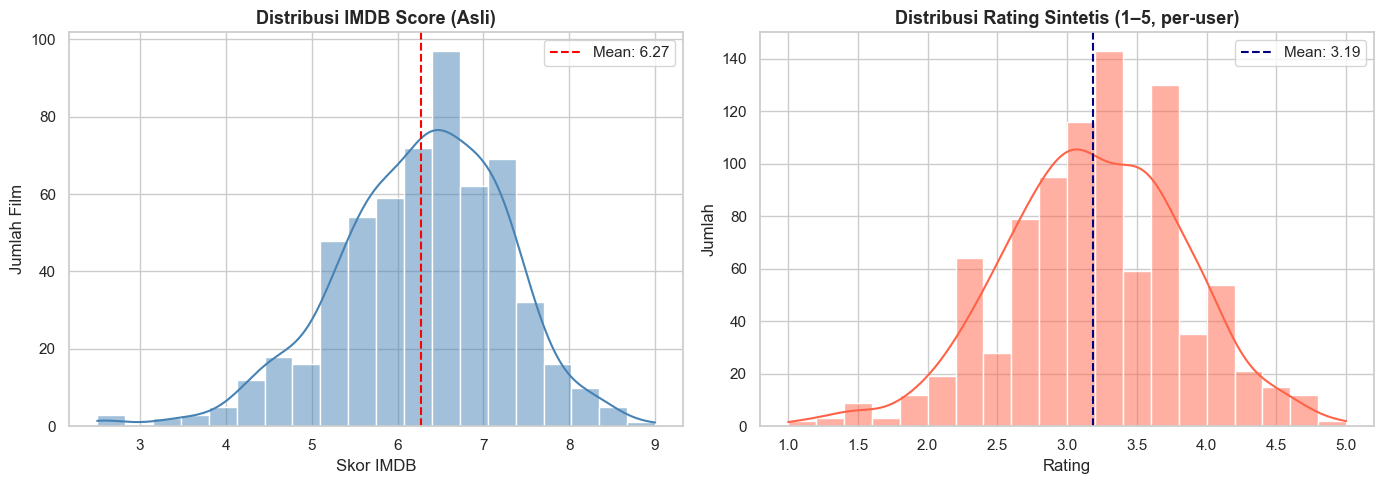

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df['IMDB Score'], bins=20, kde=True, color='steelblue', ax=axes[0])
axes[0].axvline(df['IMDB Score'].mean(), color='red', linestyle='--', label=f'Mean: {df["IMDB Score"].mean():.2f}')
axes[0].set_title('Distribusi IMDB Score (Asli)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Skor IMDB')
axes[0].set_ylabel('Jumlah Film')
axes[0].legend()

sns.histplot(df_merged['rating'], bins=20, kde=True, color='tomato', ax=axes[1])
axes[1].axvline(df_merged['rating'].mean(), color='navy', linestyle='--', label=f'Mean: {df_merged["rating"].mean():.2f}')
axes[1].set_title('Distribusi Rating Sintetis (1–5, per-user)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Rating')
axes[1].set_ylabel('Jumlah')
axes[1].legend()

plt.tight_layout()
plt.show()

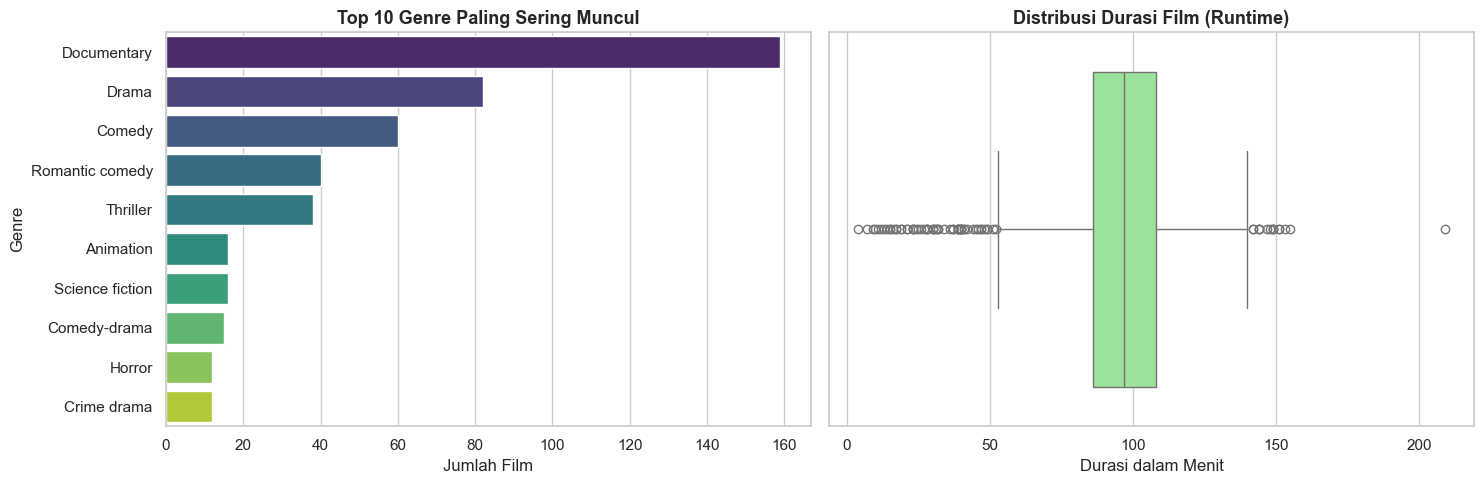

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

all_genres = df['Genre'].dropna().str.split('/').explode().str.strip()
top_genres = all_genres.value_counts().head(10)
sns.barplot(x=top_genres.values, y=top_genres.index, palette='viridis', ax=axes[0])
axes[0].set_title('Top 10 Genre Paling Sering Muncul', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Jumlah Film')

sns.boxplot(x=df['Runtime'], color='lightgreen', ax=axes[1])
axes[1].set_title('Distribusi Durasi Film (Runtime)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Durasi dalam Menit')

plt.tight_layout()
plt.show()

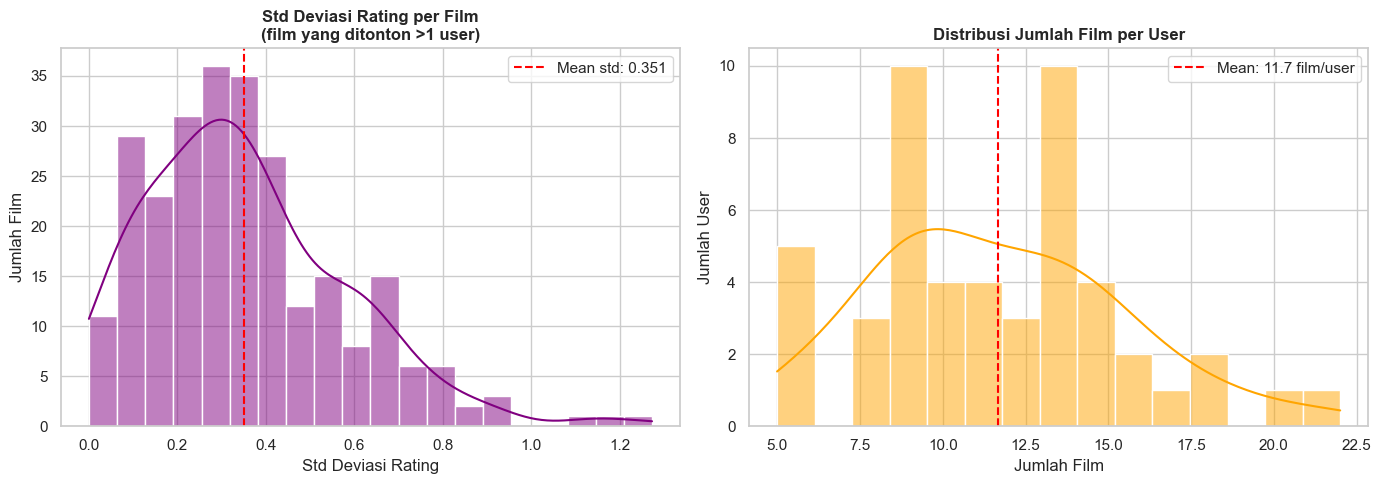

Film dengan > 1 penonton : 262
Rata-rata std rating    : 0.3508
Std > 0 berarti rating berbeda antar user


In [21]:
rating_std = df_merged.groupby('Title')['rating'].agg(['std', 'count'])
rating_std = rating_std[rating_std['count'] > 1]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(rating_std['std'].dropna(), bins=20, color='purple', kde=True, ax=axes[0])
axes[0].set_title(
    'Std Deviasi Rating per Film\n(film yang ditonton >1 user)',
    fontsize=12, fontweight='bold'
)
axes[0].set_xlabel('Std Deviasi Rating')
axes[0].set_ylabel('Jumlah Film')
axes[0].axvline(
    rating_std['std'].mean(), color='red', linestyle='--',
    label=f'Mean std: {rating_std["std"].mean():.3f}'
)
axes[0].legend()

user_counts = df.groupby('User').size().sort_values(ascending=False)
sns.histplot(user_counts, bins=15, color='orange', kde=True, ax=axes[1])
axes[1].set_title('Distribusi Jumlah Film per User', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Jumlah Film')
axes[1].set_ylabel('Jumlah User')
axes[1].axvline(
    user_counts.mean(), color='red', linestyle='--',
    label=f'Mean: {user_counts.mean():.1f} film/user'
)
axes[1].legend()

plt.tight_layout()
plt.show()

print(f'Film dengan > 1 penonton : {len(rating_std)}')
print(f'Rata-rata std rating    : {rating_std["std"].mean():.4f}')
if rating_std['std'].mean() > 0:
    print('Std > 0 berarti rating berbeda antar user')
else:
    print('Rating homogen, CF tidak akan belajar pola personal')

## Data Preprocessing

In [ ]:
df['Genre']      = df['Genre'].fillna('')
df['Language']   = df['Language'].fillna('')
df['Real_Actor'] = df['Real_Actor'].fillna('')
df['Overview'] = df['Overview'].fillna('')

print('Missing values setelah fill:')
print(df[['Genre', 'Language', 'Real_Actor', 'Overview']].isnull().sum())

Missing values setelah fill:
Genre         0
Language      0
Real_Actor    0
Overview      0
dtype: int64


In [45]:
import unicodedata
import re

def parse_genre_set(g: str) -> set:
    parts = re.split(r'[/,]', g.lower().strip())
    return {p.strip() for p in parts if p.strip()}

def genre_overlap(g1: str, g2: str) -> int:
    return len(parse_genre_set(g1) & parse_genre_set(g2))

def genre_compatible(src_genre: str, cand_genre: str) -> bool:
    src_set  = parse_genre_set(src_genre)
    cand_set = parse_genre_set(cand_genre)

    if len(src_set & cand_set) >= 1:
        return True

    src_words  = set(' '.join(src_set).replace('-', ' ').split())
    cand_words = set(' '.join(cand_set).replace('-', ' ').split())
    return len(src_words & cand_words) >= 1

def clean_tag_field(x):
    if not isinstance(x, str) or not x.strip():
        return ''
    x = unicodedata.normalize('NFKD', x).encode('ascii', 'ignore').decode('utf-8')
    sep = ',' if ',' in x else '/'
    tokens = [re.sub(r'\s+', '', t.lower().strip()) for t in x.split(sep)]
    return ' '.join(tokens)

def clean_overview(x):
    if not isinstance(x, str) or not x.strip():
        return ''
    x = unicodedata.normalize('NFKD', x).encode('ascii', 'ignore').decode('utf-8')
    x = re.sub(r'[^a-z0-9\s]', '', x.lower())
    return re.sub(r'\s+', ' ', x).strip()

In [46]:
df['genre_clean']    = df['Genre'].map(clean_tag_field)
df['lang_clean']     = df['Language'].map(clean_tag_field)
df['actor_clean']    = df['Real_Actor'].map(clean_tag_field)
df['overview_clean'] = df['Overview'].fillna('').map(clean_overview)

df['tags'] = (
    df['genre_clean'].apply(lambda x: ' '.join([x] * 5)) + ' ' +
    df['lang_clean'].apply(lambda x: ' '.join([x] * 2)) + ' ' +
    df['actor_clean'] + ' ' +
    df['overview_clean']
).apply(lambda x: ' '.join(x.split()))

print(df[['Title', 'tags']].head(3).to_string())
print(f"\nRata-rata panjang tags: {df['tags'].str.split().apply(len).mean():.0f} kata")

             Title                                                                                                                                                                                                                                                                                                                                                                                                                                                       tags
0  Enter the Anime                                                                                                                                                           documentary documentary documentary documentary documentary english japanese english japanese kouzoumorishita kenjikamiyama yokotakahashi shinjiaramaki what is anime through deepdives with notable masterminds of this electrifying genre this fastpaced documentary seeks to find the answers
1      Dark Forces                                                          

In [24]:
df.head(3)

,Title,Genre,Premiere,Runtime,IMDB Score,Language,Year,Real_Actor,Overview,tags,User
0,Enter the Anime,Documentary,"August 5, 2019",58,2.5,English/Japanese,2019,"Kouzou Morishita, Kenji Kamiyama, Yoko Takahas...",What is anime? Through deep-dives with notable...,documentary documentary documentary english ja...,User_039
1,Dark Forces,Thriller,"August 21, 2020",81,2.6,Spanish,2020,"Tenoch Huerta MejÃ­a, ErÃ©ndira Ibarra, Ariane...","In search of his sister, a renegade criminal s...",thriller thriller thriller spanish tenochhuert...,User_029
2,The App,Science fiction/Drama,"December 26, 2019",79,2.6,Italian,2019,"Vincenzo Crea, Jessica Cressy, Greta Scarano, ...","Loving girlfriend, family fortune, breakout mo...",sciencefiction drama sciencefiction drama scie...,User_015


## Feature Engineering

In [ ]:
tfidf = TfidfVectorizer(ngram_range=(1, 2), min_df=2, sublinear_tf=True)
tfidf_matrix = tfidf.fit_transform(df['tags'])

scaler = MinMaxScaler()
num_features = scaler.fit_transform(
    df[['IMDB Score', 'Runtime']].fillna(df[['IMDB Score', 'Runtime']].median())
)
num_sparse   = sp.csr_matrix(num_features * 0.15)
combined_matrix = sp.hstack([tfidf_matrix, num_sparse])

cosine_sim = cosine_similarity(combined_matrix, combined_matrix)
indices    = pd.Series(df.index, index=df['Title']).groupby(level=0).first()

Shape: (584, 584)


In [26]:
user_encoder  = LabelEncoder()
movie_encoder = LabelEncoder()

df_merged['user_idx']  = user_encoder.fit_transform(df_merged['User'])
df_merged['movie_idx'] = movie_encoder.fit_transform(df_merged['Title'])

n_users  = df_merged['user_idx'].nunique()
n_movies = df_merged['movie_idx'].nunique()

df_merged['rating_norm'] = (df_merged['rating'] - 1.0) / 4.0

print('\nSample fitur siap training NCF:')
print(df_merged[['Title', 'User', 'user_idx', 'movie_idx', 'rating', 'rating_norm']].head(3))


Sample fitur siap training NCF:
                         Title      User  user_idx  movie_idx  rating  \
0  Baggio: The Divine Ponytail  User_001         0         48     2.8   
1                      Cadaver  User_001         0         70     3.0   
2                   Below Zero  User_001         0         54     4.5   

   rating_norm  
0        0.450  
1        0.500  
2        0.875  


In [27]:
df_merged['rating_norm'] = (df_merged['rating'] - 1.0) / 4.0

df_merged[['Title', 'User', 'user_idx', 'movie_idx', 'rating', 'rating_norm']].head()

,Title,User,user_idx,movie_idx,rating,rating_norm
0,Baggio: The Divine Ponytail,User_001,0,48,2.8,0.450
1,Cadaver,User_001,0,70,3.0,0.500
2,Below Zero,User_001,0,54,4.5,0.875
3,Winter on Fire: Ukraine's Fight for Freedom,User_001,0,472,4.0,0.750
4,"Strip Down, Rise Up",User_001,0,343,2.4,0.350


In [28]:
X = df_merged[['user_idx', 'movie_idx']].values
y = df_merged['rating_norm'].values

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=SEED
)

print(f'Train set : {X_train.shape[0]:,} baris')
print(f'Val set   : {X_val.shape[0]:,} baris')

Train set : 720 baris
Val set   : 181 baris


## 6. Model Training

### Model 1 TF-IDF Content-Based Filtering

In [48]:
def recommend_popular(top_n: int = 10) -> pd.DataFrame:
    return (
        df[['Title', 'Genre', 'IMDB Score', 'Runtime', 'Language']]
        .sort_values('IMDB Score', ascending=False)
        .drop_duplicates(subset='Title')
        .head(top_n)
        .reset_index(drop=True)
    )

def get_cbf_recommendations(
    title: str,
    top_n: int = 10,
    min_similarity: float = 0.05,
    relative_cutoff: float = 0.25,
    genre_filter: bool = True,
    verbose: bool = False
) -> pd.DataFrame:
    if title not in indices:
        print(f"[!] '{title}' tidak ditemukan.")
        return pd.DataFrame()

    idx       = indices[title]
    src_genre = df.loc[idx, 'Genre']
    sims      = sorted(enumerate(cosine_sim[idx]), key=lambda x: x[1], reverse=True)
    sims      = [(i, s) for i, s in sims if i != idx and s >= min_similarity]

    if not sims:
        return recommend_popular(top_n)

    top_score = sims[0][1]
    sims = [(i, s) for i, s in sims if s >= top_score * relative_cutoff]

    if genre_filter:
        sims = [(i, s) for i, s in sims
                if genre_compatible(src_genre, df.loc[i, 'Genre'])]

    n_organic = len(sims)
    if verbose and n_organic < top_n:
        print(f"[i] '{title}': {n_organic} hasil organik dari {top_n} diminta.")

    if not sims:
        return recommend_popular(top_n)

    top_idx    = [i for i, _ in sims[:top_n]]
    top_scores = [round(s, 4) for _, s in sims[:top_n]]
    result = df[['Title', 'Genre', 'IMDB Score', 'Runtime', 'Language']].iloc[top_idx].copy()
    result['similarity_score'] = top_scores
    return result.reset_index(drop=True)

sample_title = df['Title'].iloc[0]
get_cbf_recommendations(sample_title, top_n=5)

,Title,Genre,IMDB Score,Runtime,Language,similarity_score
0,Little Miss Sumo,Documentary,6.7,19,Japanese,0.3470
1,Notes from Dunblane: Lesson from a School Shoo...,Documentary,5.9,23,English,0.2577
2,Voyuer,Documentary,6.2,95,English,0.2577
3,The Legend of Cocaine Island,Documentary,6.3,87,English,0.2577
4,A Love Song for Latasha,Documentary,6.8,19,English,0.2577


### Model 2 Neural Collaborative Filtering

In [47]:
EMBED_DIM = 32   
MLP_UNITS = [64, 32, 16]  

def build_ncf(n_users: int, n_movies: int,
              embed_dim: int = EMBED_DIM,
              mlp_units: list = MLP_UNITS) -> keras.Model:
    
    user_input  = layers.Input(shape=(1,), name='user_input')
    movie_input = layers.Input(shape=(1,), name='movie_input')

    user_emb_mf  = layers.Embedding(n_users,  embed_dim,
                                    embeddings_regularizer='l2',
                                    name='user_emb_mf')(user_input)
    movie_emb_mf = layers.Embedding(n_movies, embed_dim,
                                    embeddings_regularizer='l2',
                                    name='movie_emb_mf')(movie_input)
    mf_vec = layers.Multiply(name='mf_multiply')([user_emb_mf, movie_emb_mf])
    mf_out = layers.Flatten(name='mf_flatten')(mf_vec)

    user_emb_mlp  = layers.Embedding(n_users,  embed_dim,
                                     embeddings_regularizer='l2',
                                     name='user_emb_mlp')(user_input)
    movie_emb_mlp = layers.Embedding(n_movies, embed_dim,
                                     embeddings_regularizer='l2',
                                     name='movie_emb_mlp')(movie_input)
    mlp_vec = layers.Concatenate(name='mlp_concat')(
        [layers.Flatten()(user_emb_mlp), layers.Flatten()(movie_emb_mlp)]
    )
    x = mlp_vec
    for units in mlp_units:
        x = layers.Dense(units, activation='relu')(x)
        x = layers.Dropout(0.2)(x)
    mlp_out = x

    combined = layers.Concatenate(name='fusion')([mf_out, mlp_out])
    output   = layers.Dense(1, activation='sigmoid', name='output')(combined)

    model = keras.Model(
        inputs=[user_input, movie_input],
        outputs=output,
        name='NCF_TwoTower'
    )
    return model


ncf_model = build_ncf(n_users, n_movies)
ncf_model.summary()

Model: "NCF_TwoTower"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ user_input          │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ movie_input         │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ user_emb_mlp        │ (None, 1, 32)     │      1,600 │ user_input[0][0]  │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ movie_emb_mlp       │ (None, 1, 32)     │     15,360 │ movie_input[0][0] │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 32)        │          0 │ user_emb_mlp[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_1 (Flatten) │ (None, 32)        │          0 │ movie_emb_mlp[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mlp_concat          │ (None, 64)        │          0 │ flatten[0][0],    │
│ (Concatenate)       │                   │            │ flatten_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 64)        │      4,160 │ mlp_concat[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 64)        │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 32)        │      2,080 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ user_emb_mf         │ (None, 1, 32)     │      1,600 │ user_input[0][0]  │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ movie_emb_mf        │ (None, 1, 32)     │     15,360 │ movie_input[0][0] │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 32)        │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mf_multiply         │ (None, 1, 32)     │          0 │ user_emb_mf[0][0… │
│ (Multiply)          │                   │            │ movie_emb_mf[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 16)        │        528 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mf_flatten          │ (None, 32)        │          0 │ mf_multiply[0][0] │
│ (Flatten)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 16)        │          0 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ fusion              │ (None, 48)        │          0 │ mf_flatten[0][0], │
│ (Concatenate)       │                   │            │ dropout_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output (Dense)      │ (None, 1)         │         49 │ fusion[0][0]      │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 40,737 (159.13 KB)

 Trainable params: 40,737 (159.13 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping
# Compile Model
ncf_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='mean_squared_error',
    metrics=['mae']
)

# Rem Otomatis
early_stop = EarlyStopping(
    monitor='val_mae',
    patience=3,          # Toleransi nunggu 3 epoch sebelum di-cut
    restore_best_weights=True, # Kembalikan bobot model ke titik paling optimal
    verbose=1
)

# Eksekusi Training 
print("Memulai proses training NCF")
history = ncf_model.fit(
    x=[X_train[:, 0], X_train[:, 1]], 
    y=y_train,                                   
    validation_data=([X_val[:, 0], X_val[:, 1]], y_val),
    batch_size=64,
    epochs=25, 
    callbacks=[early_stop]
)

Memulai proses training NCF
Epoch 1/25
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - loss: 0.2365 - mae: 0.1344 - val_loss: 0.1544 - val_mae: 0.1288
Epoch 2/25
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.1146 - mae: 0.1320 - val_loss: 0.0747 - val_mae: 0.1276
Epoch 3/25
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0569 - mae: 0.1301 - val_loss: 0.0419 - val_mae: 0.1275
Epoch 4/25
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0347 - mae: 0.1301 - val_loss: 0.0310 - val_mae: 0.1278
Epoch 5/25
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0278 - mae: 0.1290 - val_loss: 0.0281 - val_mae: 0.1276
Epoch 6/25
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0260 - mae: 0.1286 - val_loss: 0.0277 - val_mae: 0.1276
Epoch 6: early stopping
Restoring model weights from the end of the best epoch: 3.


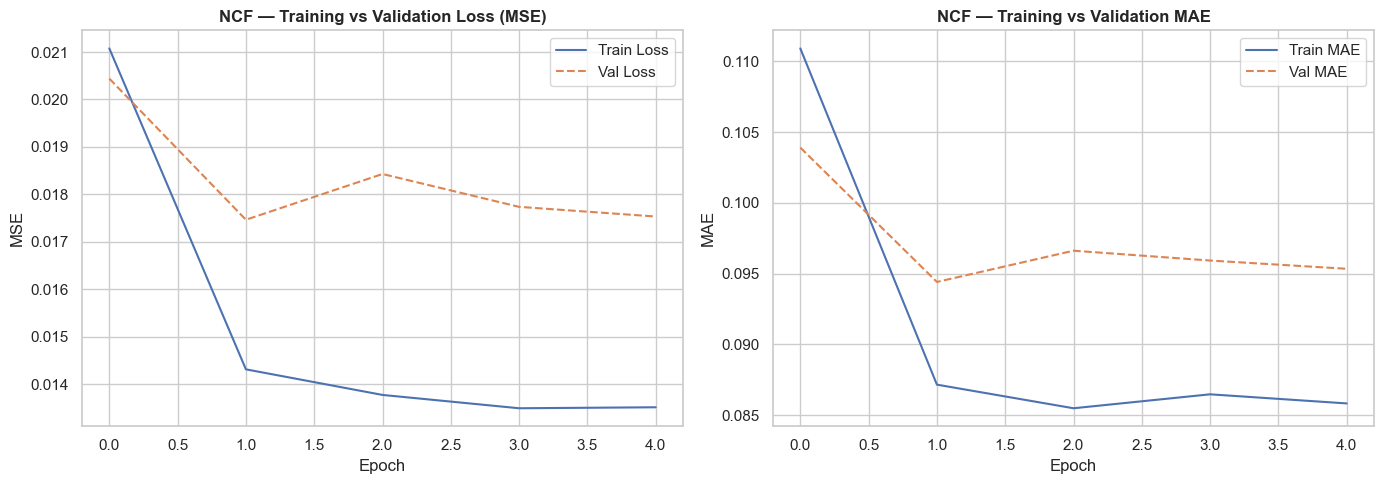

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history['loss'],     label='Train Loss')
axes[0].plot(history.history['val_loss'], label='Val Loss', linestyle='--')
axes[0].set_title('NCF — Training vs Validation Loss (MSE)', fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('MSE')
axes[0].legend()

axes[1].plot(history.history['mae'],     label='Train MAE')
axes[1].plot(history.history['val_mae'], label='Val MAE', linestyle='--')
axes[1].set_title('NCF — Training vs Validation MAE', fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('MAE')
axes[1].legend()

plt.tight_layout()
plt.show()

In [ ]:
def get_ncf_recommendations(
    username: str,
    top_n: int = 10,
    exclude_seen: bool = True
) -> pd.DataFrame:
    if username not in user_encoder.classes_:
        return pd.DataFrame({'error': [f'User "{username}" tidak ditemukan.']})

    user_id   = user_encoder.transform([username])[0]
    all_movie_ids = np.arange(n_movies)

    # PERBAIKAN: Gunakan df_merged untuk mencari riwayat tontonan
    seen_movie_ids = set(
        df_merged[df_merged['User'] == username]['movie_idx'].values
    ) if exclude_seen else set()

    # Prediksi untuk semua film
    user_arr  = np.full(len(all_movie_ids), user_id)
    preds     = ncf_model.predict(
        [user_arr, all_movie_ids], verbose=0
    ).flatten()

    # Konversi prediksi ke skala 1–5
    pred_ratings = preds * 4.0 + 1.0

    # Buat DataFrame hasil
    result = pd.DataFrame({
        'movie_idx':   all_movie_ids,
        'pred_rating': pred_ratings
    })

    # Kecualikan film yang sudah ditonton
    if exclude_seen:
        result = result[~result['movie_idx'].isin(seen_movie_ids)]

    # Urutkan & ambil top-N
    result = result.sort_values('pred_rating', ascending=False).head(top_n)

    # Decode movie_idx → judul
    result['Title'] = movie_encoder.inverse_transform(
        result['movie_idx'].values
    )

    # Gabung dengan metadata 
    meta = df[['Title', 'Genre', 'IMDB Score', 'Language']].drop_duplicates('Title')
    result = result.merge(meta, on='Title', how='left')
    result['pred_rating'] = result['pred_rating'].round(2)

    return result[['Title', 'Genre', 'IMDB Score', 'Language', 'pred_rating']].reset_index(drop=True)


sample_user = fake_users[0]
get_ncf_recommendations(sample_user, top_n=5)

,Title,Genre,IMDB Score,Language,pred_rating
0,Hillbilly Elegy,Drama,6.7,English,3.21
1,The Old Guard,Superhero/Action,6.7,English,3.21
2,The Social Dilemma,Documentary,7.6,English,3.21
3,Sand Castle,War,6.3,English,3.21
4,The Christmas Chronicles,Christmas/Fantasy/Adventure/Comedy,7.0,English,3.21


### Model 3 Hybrid Onboarding 

In [ ]:
def hybrid_onboarding_recommendations(
    liked_titles: list,
    top_n: int = 10
) -> pd.DataFrame:
    valid = [t for t in liked_titles if t in indices]
    invalid = [t for t in liked_titles if t not in indices]

    if invalid:
        print(f'Film tidak ditemukan dan diabaikan: {invalid}')

    if not valid:
        print('tidak ada film valid. Menampilkan rekomendasi populer...')
        return recommend_popular(top_n)

    # Ambil TF-IDF vector → mean pooling
    liked_idx    = [indices[t] for t in valid]
    liked_matrix = tfidf_matrix[liked_idx]           # sparse (k × vocab)
    mean_vector = np.asarray(liked_matrix.mean(axis=0))         # dense (1 × vocab)

    # Cosine similarity antara mean vector dan semua film
    sims = cosine_similarity(mean_vector, tfidf_matrix).flatten()

    # Kecualikan film yang sudah disukai
    for idx in liked_idx:
        sims[idx] = -1.0

    top_idx    = sims.argsort()[::-1][:top_n]
    top_scores = sims[top_idx]

    result = df[['Title', 'Genre', 'IMDB Score', 'Language']].iloc[top_idx].copy()
    result['onboarding_score'] = np.round(top_scores, 4)
    return result.reset_index(drop=True)


# Test dengan 3 film acak
liked_sample = df['Title'].drop_duplicates().sample(3, random_state=SEED).tolist()
print(f'Film yang disukai user baru: {liked_sample}\n')
hybrid_onboarding_recommendations(liked_sample, top_n=5)

Film yang disukai user baru: ['Paper Lives', 'Outlaw King', 'Things Heard & Seen']



,Title,Genre,IMDB Score,Language,onboarding_score
0,Mank,Biopic,6.9,English,0.1287
1,Stuck Apart,Drama,6.1,Turkish,0.1035
2,The Death and Life of Marsha P. Johnson,Documentary,7.3,English,0.0947
3,The Perfection,Horror-thriller,6.1,English,0.0913
4,Concrete Cowboy,Drama,6.3,English,0.0908


## Evaluasi Model

# CBF

In [49]:
def build_genre_ground_truth(df: pd.DataFrame, min_shared_genres: int = 1) -> dict:
    ground_truth = {}
    for i, row in df.iterrows():
        src = parse_genre_set(row['Genre'])
        relevant = []
        for j, row2 in df.iterrows():
            if i == j:
                continue
            if len(src & parse_genre_set(row2['Genre'])) >= min_shared_genres:
                relevant.append(row2['Title'])
        ground_truth[row['Title']] = set(relevant)
    return ground_truth

def evaluate_cbf(
    ground_truth: dict,
    k_values: list = [5, 10, 20],
    sample_n: int = 50,
    random_state: int = 42
) -> pd.DataFrame:
    np.random.seed(random_state)
    sample_titles = (
        df['Title'].drop_duplicates()
        .sample(min(sample_n, len(df)), random_state=random_state)
        .tolist()
    )
    results = []
    for k in k_values:
        precisions, recalls, coverages = [], [], []
        for title in sample_titles:
            if title not in ground_truth or title not in indices:
                continue
            recs = get_cbf_recommendations(title, top_n=k, verbose=False)
            if recs.empty:
                continue
            recommended_set = set(recs['Title'].tolist())
            relevant_set    = ground_truth[title]
            if not relevant_set:
                continue
            tp = len(recommended_set & relevant_set)
            precisions.append(tp / k)
            recalls.append(tp / len(relevant_set))
            coverages.append(len(recommended_set) / k)

        p = np.mean(precisions)
        r = np.mean(recalls)
        results.append({
            'k'           : k,
            'precision@k' : round(p, 4),
            'recall@k'    : round(r, 4),
            'f1@k'        : round(2 * p * r / (p + r + 1e-9), 4),
            'coverage'    : round(np.mean(coverages), 4),
            'n_evaluated' : len(precisions)
        })

    print("\n=== Evaluasi CBF ===")
    print(pd.DataFrame(results).to_string(index=False))
    print("\nCatatan: coverage < 1.0 artinya genre terlalu langka di dataset.")
    return pd.DataFrame(results)

# Jalankan
print("Membangun ground truth...")
gt = build_genre_ground_truth(df, min_shared_genres=1)

print("Mengevaluasi...")
eval_df = evaluate_cbf(gt, k_values=[5, 10, 20], sample_n=100)

Membangun ground truth...
Mengevaluasi...

=== Evaluasi CBF ===
 k  precision@k  recall@k   f1@k  coverage  n_evaluated
 5       0.9319    0.2825 0.4335    0.9745           94
10       0.8553    0.3703 0.5168    0.9096           94
20       0.7665    0.4791 0.5896    0.8271           94

Catatan: coverage < 1.0 artinya genre terlalu langka di dataset.


In [ ]:
y_pred_norm = ncf_model.predict(
    [X_val[:, 0], X_val[:, 1]], verbose=0
).flatten()

# Denormalisasi ke skala 1–5
y_pred_orig = y_pred_norm * 4.0 + 1.0
y_true_orig = y_val       * 4.0 + 1.0

rmse = np.sqrt(mean_squared_error(y_true_orig, y_pred_orig))
mae  = np.mean(np.abs(y_true_orig - y_pred_orig))

print('=== Evaluasi NCF (Validation Set) ===')
print(f'RMSE : {rmse:.4f}  (skala 1–5)')
print(f'MAE  : {mae:.4f}  (skala 1–5)')

=== Evaluasi NCF (Validation Set) ===
RMSE : 0.4964  (skala 1–5)
MAE  : 0.3776  (skala 1–5)


# NCF

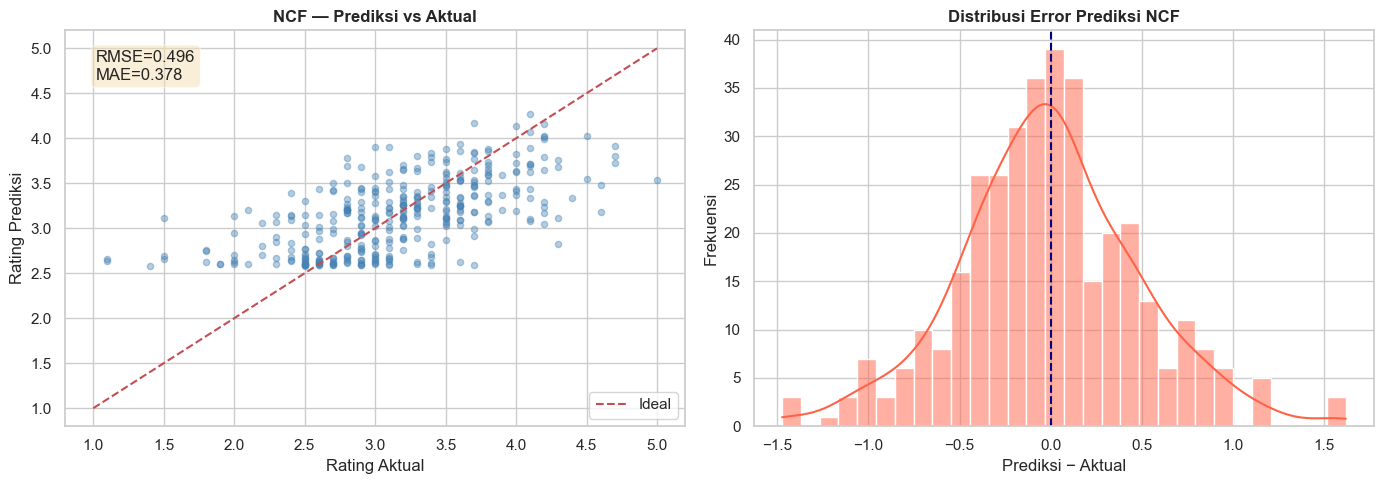

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter
axes[0].scatter(y_true_orig, y_pred_orig, alpha=0.4, color='steelblue', s=20)
axes[0].plot([1, 5], [1, 5], 'r--', linewidth=1.5, label='Ideal')
axes[0].set_title('NCF — Prediksi vs Aktual', fontweight='bold')
axes[0].set_xlabel('Rating Aktual')
axes[0].set_ylabel('Rating Prediksi')
axes[0].legend()
axes[0].text(
    0.05, 0.95, f'RMSE={rmse:.3f}\nMAE={mae:.3f}',
    transform=axes[0].transAxes, verticalalignment='top',
    bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5)
)

# Distribusi error
errors = y_pred_orig - y_true_orig
sns.histplot(errors, bins=30, kde=True, color='tomato', ax=axes[1])
axes[1].axvline(0, color='navy', linestyle='--')
axes[1].set_title('Distribusi Error Prediksi NCF', fontweight='bold')
axes[1].set_xlabel('Prediksi − Aktual')
axes[1].set_ylabel('Frekuensi')

plt.tight_layout()
plt.show()

In [53]:
total_items = df['Title'].nunique()
can_recommend = (cosine_sim > 0).sum(axis=1) > 1 
coverage = can_recommend.sum() / len(can_recommend) * 100

print('Evaluasi Content-Based Filtering')
print(f'Total item    : {total_items}')
print(f'Coverage      : {coverage:.1f}%')
print(f' {coverage:.1f}% item dapat direkomendasikan ke user lain')

Evaluasi Content-Based Filtering
Total item    : 584
Coverage      : 100.0%
 100.0% item dapat direkomendasikan ke user lain


## Simpan Model

In [ ]:
os.makedirs('model', exist_ok=True)

# NCF Model 
ncf_model.save('model/ncf_model.keras')

# TF-IDF vectorizer & cosine sim matrix
joblib.dump(tfidf,      'model/tfidf_vectorizer.pkl')
joblib.dump(cosine_sim, 'model/cosine_sim_matrix.pkl')

# Label Encoders
joblib.dump(user_encoder,  'model/user_encoder.pkl')
joblib.dump(movie_encoder, 'model/movie_encoder.pkl')

# Dataset + features
df.to_csv('model/df_processed.csv', index=False)

## Test Sistem Rekomendasi


In [52]:
genre = df.loc[df['Title'] == 'The Open House'].values[0]
print(f"Genre Searching : {genre}")

Genre Searching : ['The Open House' 'Horror thriller' 'January 19, 2018' 94 3.2 'English'
 2018 'Dylan Minnette, Piercey Dalton, Sharif Atkins, Patricia Bethune'
 'A teenager and his mother find themselves besieged by threatening forces when they move into a new house.'
 'horrorthriller horrorthriller horrorthriller horrorthriller horrorthriller english english dylanminnette pierceydalton sharifatkins patriciabethune a teenager and his mother find themselves besieged by threatening forces when they move into a new house'
 'User_043' 'horrorthriller' 'english'
 'dylanminnette pierceydalton sharifatkins patriciabethune'
 'a teenager and his mother find themselves besieged by threatening forces when they move into a new house']


In [43]:
for title in ['The Open House', 'Dark Forces', 'The App']:
    print(f"\nTop 5 rekomendasi untuk '{title}':")
    result = get_cbf_recommendations(title, top_n=5, verbose=True)
    if not result.empty:
        print(result[['Title', 'Genre', 'IMDB Score', 'similarity_score']].to_string(index=False))
    print("=" * 65)


Top 5 rekomendasi untuk 'The Open House':
[i] 'The Open House': 2 hasil organik dari 5 diminta.
        Title           Genre  IMDB Score  similarity_score
Gerald's Game Horror thriller         6.5            0.4602
   Death Note Horror thriller         4.4            0.3883

Top 5 rekomendasi untuk 'Dark Forces':
                Title    Genre  IMDB Score  similarity_score
Offering to the Storm Thriller         6.2            0.2507
        The Paramedic Thriller         5.6            0.2364
            Intuition Thriller         5.3            0.2124
             AK vs AK Thriller         6.9            0.1971
         The Occupant Thriller         6.4            0.1814

Top 5 rekomendasi untuk 'The App':
                         Title                       Genre  IMDB Score  similarity_score
                            IO       Science fiction/Drama         4.7            0.2718
                 The Discovery       Science fiction/Drama         6.3            0.2384
              

In [ ]:
demo_user = fake_users[5]
print(f'Model 2 NCF Rekomendasi untuk {demo_user}:')
print(get_ncf_recommendations(demo_user, top_n=5).to_string(index=False))

Model 2 NCF Rekomendasi untuk User_006:
                                      Title       Genre  IMDB Score                 Language  pred_rating
                 The Trial of the Chicago 7       Drama         7.8                  English         4.22
   David Attenborough: A Life on Our Planet Documentary         9.0                  English         4.17
                    Cuba and the Cameraman  Documentary         8.3                  English         4.12
          Disclosure: Trans Lives on Screen Documentary         8.2                  English         4.02
Winter on Fire: Ukraine's Fight for Freedom Documentary         8.4 English/Ukranian/Russian         4.01


In [ ]:
onboarding_likes = df['Title'].drop_duplicates().sample(3, random_state=7).tolist()
print(f'Model 3 Hybrid Onboarding User baru menyukai : {onboarding_likes}')
print(hybrid_onboarding_recommendations(onboarding_likes, top_n=5).to_string(index=False))

Model 3 Hybrid Onboarding User baru menyukai : ['Night in Paradise', 'Prime Time', 'Blue Miracle']
            Title        Genre  IMDB Score Language  onboarding_score
Pieces of a Woman        Drama         7.1  English            0.4269
  Concrete Cowboy        Drama         6.3  English            0.4269
  Imperial Dreams        Drama         6.7  English            0.4269
   The Polka King Comedy-drama         5.9  English            0.3577
       Lovefucked        Drama         6.0    Hindi            0.3258


In [ ]:
print('User tanpa riwayat Top Film Populer:')
print(recommend_popular(top_n=5).to_string(index=False))

User tanpa riwayat Top Film Populer:
                                     Title        Genre  IMDB Score   Language
  David Attenborough: A Life on Our Planet  Documentary         9.0    English
 Emicida: AmarElo - It's All For Yesterday  Documentary         8.6 Portuguese
                   Springsteen on Broadway One-man show         8.5    English
     Taylor Swift: Reputation Stadium Tour Concert Film         8.4    English
Ben Platt: Live from Radio City Music Hall Concert Film         8.4    English


In [ ]:
judul_rekomendasi = 'The Trial of the Chicago 7'

fav_user_001 = df_merged[(df_merged['User'] == 'User_001') & (df_merged['rating'] >= 4.0)]['Title'].tolist()
print(f"Film Favorit User_001: {fav_user_001}\n")
print("-" * 50)

teman_frekuensi = df_merged[
    (df_merged['Title'].isin(fav_user_001)) & 
    (df_merged['rating'] >= 4.0) & 
    (df_merged['User'] != 'User_001')
]['User'].unique()
print(f"Ditemukan {len(teman_frekuensi)} user lain yang seleranya mirip dengan User_001.\n")
print("-" * 50)

bukti_nyata = df_merged[
    (df_merged['User'].isin(teman_frekuensi)) & 
    (df_merged['Title'] == judul_rekomendasi)
]

print(f"Rating dari 'Teman Frekuensi' untuk '{judul_rekomendasi}':")
print(bukti_nyata[['User', 'Title', 'rating']].sort_values('rating', ascending=False).head(10).to_string(index=False))

🎬 Film Favorit User_001: ['Below Zero', "Winter on Fire: Ukraine's Fight for Freedom", 'The Trial of the Chicago 7', 'Reversing Roe', 'Anima']

--------------------------------------------------
👥 Ditemukan 2 user lain yang seleranya mirip dengan User_001.

--------------------------------------------------
🔍 BUKTI NYATA: Rating dari 'Teman Frekuensi' untuk 'The Trial of the Chicago 7':
    User                      Title  rating
User_038 The Trial of the Chicago 7     4.1
